In [7]:
install.packages("readr") # Package to read csv file

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [9]:
library(readr)

In [10]:
library(dplyr)

In [11]:
library(tidyr)

In [12]:
df <- read.csv("asd_model (1).csv")

In [13]:
df

case_no_patients,age_years,speech_delay_language_disorder,learning_disorder,genetic_disorders,depression,global_developmental_delay_intellectual_disability,anxiety_disorder,sex,ethnicity,jaundice,family_mem_with_asd,who_completed_the_test,asd_traits
<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2,Yes,Yes,Yes,Yes,Yes,Yes,F,Middle Eastern,Yes,No,Family Member,No
2,3,Yes,Yes,Yes,Yes,Yes,Yes,M,White European,Yes,No,Family Member,Yes
3,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
4,2,Yes,Yes,No,Yes,Yes,Yes,M,Hispanic,No,No,Family Member,Yes
5,2,Yes,Yes,No,Yes,Yes,Yes,F,White European,No,No,Family Member,Yes
6,2,Yes,Yes,No,Yes,Yes,Yes,M,Black,No,No,Family Member,Yes
7,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
8,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
9,3,Yes,Yes,No,Yes,Yes,Yes,M,Asian,No,No,Family Member,No


In [14]:
glimpse(df)

Rows: 1,984
Columns: 14
$ case_no_patients                                   <int> 1, 2, 3, 4, 5, 6, 7…
$ age_years                                          <int> 2, 3, 3, 2, 2, 2, 3…
$ speech_delay_language_disorder                     <chr> "Yes", "Yes", "Yes"…
$ learning_disorder                                  <chr> "Yes", "Yes", "Yes"…
$ genetic_disorders                                  <chr> "Yes", "Yes", "Yes"…
$ depression                                         <chr> "Yes", "Yes", "Yes"…
$ global_developmental_delay_intellectual_disability <chr> "Yes", "Yes", "Yes"…
$ anxiety_disorder                                   <chr> "Yes", "Yes", "Yes"…
$ sex                                                <chr> "F", "M", "M", "M",…
$ ethnicity                                          <chr> "Middle Eastern", "…
$ jaundice                                           <chr> "Yes", "Yes", "Yes"…
$ family_mem_with_asd                                <chr> "No", "No", "No", "…
$ who_completed_

In [15]:
categorical_vars <- df %>%
  select(where(is.character)) %>%  # Separating the categorical columns
  names()

In [16]:
categorical_predictors <- setdiff(categorical_vars, "asd_traits") # Separating the outcome variable to perform EDA

In [17]:
asd_categorical_1 <- df %>%
  select(asd_traits, all_of(categorical_predictors)) %>%
  pivot_longer(                                             # All the categorical columns per patient id are added to one column with their
                                               # corresponding values in another column "indexed" by asd_traits
    cols = all_of(categorical_predictors),
    names_to = "variable",
    values_to = "category"
  )

  asd_categorical_1

asd_traits,variable,category
<chr>,<chr>,<chr>
No,speech_delay_language_disorder,Yes
No,learning_disorder,Yes
No,genetic_disorders,Yes
No,depression,Yes
No,global_developmental_delay_intellectual_disability,Yes
No,anxiety_disorder,Yes
No,sex,F
No,ethnicity,Middle Eastern
No,jaundice,Yes


In [18]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [19]:
library(ggplot2)

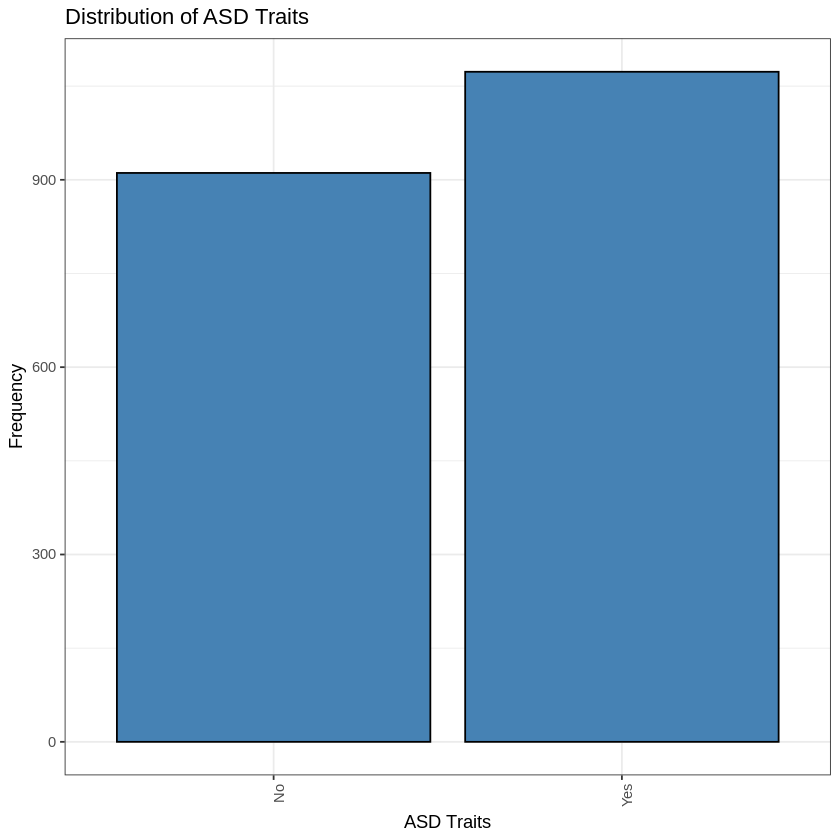

In [20]:
ggplot(df, aes(x = asd_traits)) +
    geom_bar(
      fill = "steelblue",
      color = "black"
    ) +
    labs(
      title = paste("Distribution of ASD Traits"),  # Running a loop for bar plots of all categorical values
      x = "ASD Traits",
      y = "Frequency"
    ) +
    theme_bw() +
    theme(
      axis.text.x = element_text(
        angle = 90,
        hjust = 1
      )
    )

Not a huge class imbalance wrt the outcome variable.

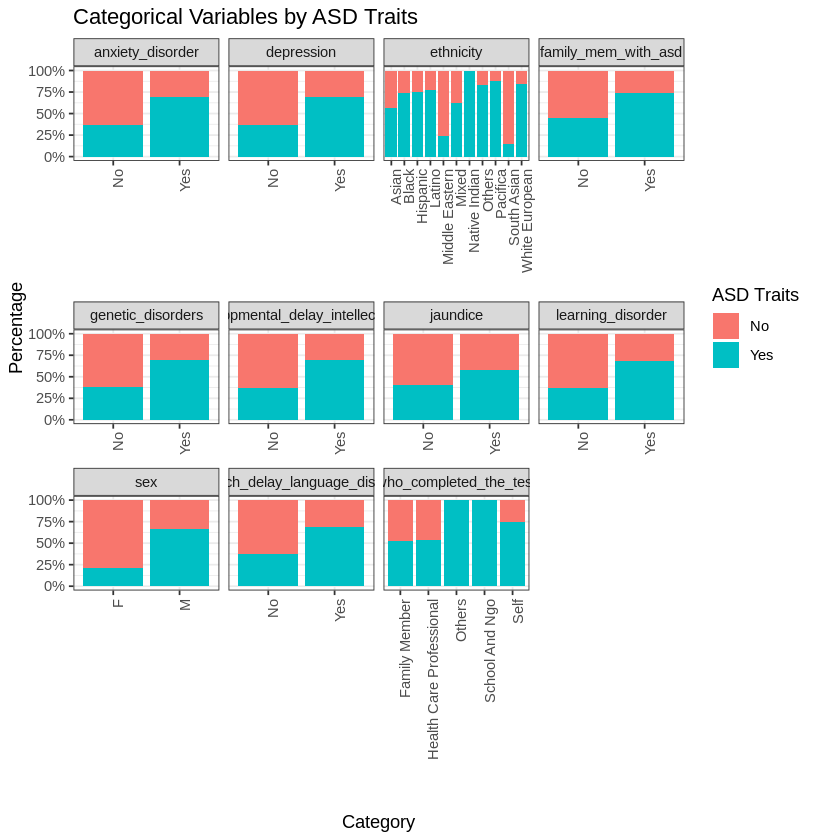

In [21]:
ggplot(asd_categorical_1, aes(x = category, fill = asd_traits)) +
  geom_bar(position = "fill") +
  facet_wrap(~ variable, scales = "free_x") +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Categorical Variables by ASD Traits",
    x = "Category",
    y = "Percentage",
    fill = "ASD Traits"       # Proportion plot for categorical values
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1
    )
  )

In [22]:
numeric_vars <- df %>%
  select(where(is.integer)) %>%  # Separating the numerical columns
  names()

In [23]:
numeric_vars <- setdiff(
  numeric_vars,                 # Removing patient id as it is not a relevant column for EDA
  "case_no_patients"
)

In [24]:
asd_numeric_1 <- df %>%
  select(asd_traits, all_of(numeric_vars)) %>%
  pivot_longer(
    cols = all_of(numeric_vars),    # All the numeric columns per patient id are added to one column with their
                                               # corresponding values in another column "indexed" by asd_traits
    names_to = "variable",
    values_to = "value"
  )

  asd_numeric_1

asd_traits,variable,value
<chr>,<chr>,<int>
No,age_years,2
Yes,age_years,3
Yes,age_years,3
Yes,age_years,2
Yes,age_years,2
Yes,age_years,2
Yes,age_years,3
Yes,age_years,3
No,age_years,3


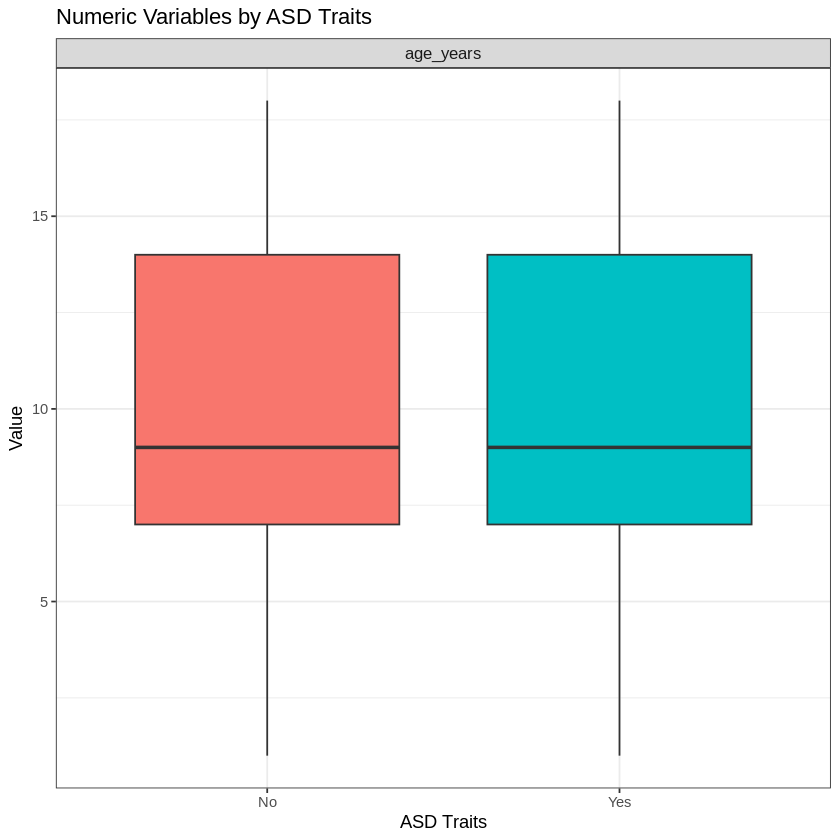

In [25]:
ggplot(asd_numeric_1, aes(x = asd_traits, y = value, fill = asd_traits)) +
  geom_boxplot(na.rm = TRUE) +
  facet_wrap(~ variable, scales = "free_y") +
  labs(
    title = "Numeric Variables by ASD Traits",
    x = "ASD Traits",                             # Boxplot of numeric columns
    y = "Value"
  ) +
  theme_bw() +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 10)
  )

The asd_traits does not have excessive class imbalance. Age distribution is similar in ASD-positive and ASD-negative traits.

Native Indians, Others, School and NGO do not have ASD negative data points and have very less occurrences.

So, it is better to drop them.



In [26]:
df1 <- df %>%
  filter(
    ethnicity != "Native Indian",
    who_completed_the_test != "School And Ngo",
    who_completed_the_test != "Others"
  )

df1

case_no_patients,age_years,speech_delay_language_disorder,learning_disorder,genetic_disorders,depression,global_developmental_delay_intellectual_disability,anxiety_disorder,sex,ethnicity,jaundice,family_mem_with_asd,who_completed_the_test,asd_traits
<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2,Yes,Yes,Yes,Yes,Yes,Yes,F,Middle Eastern,Yes,No,Family Member,No
2,3,Yes,Yes,Yes,Yes,Yes,Yes,M,White European,Yes,No,Family Member,Yes
3,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
4,2,Yes,Yes,No,Yes,Yes,Yes,M,Hispanic,No,No,Family Member,Yes
5,2,Yes,Yes,No,Yes,Yes,Yes,F,White European,No,No,Family Member,Yes
6,2,Yes,Yes,No,Yes,Yes,Yes,M,Black,No,No,Family Member,Yes
7,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
8,3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
9,3,Yes,Yes,No,Yes,Yes,Yes,M,Asian,No,No,Family Member,No


In [27]:
dim(df1)

[1] 1949   14

In [28]:
asd_categorical_2 <- df1 %>%
  select(asd_traits, all_of(categorical_predictors)) %>%
  pivot_longer(                                             # All the categorical columns per patient id are added to one column with their
                                               # corresponding values in another column "indexed" by asd_traits
    cols = all_of(categorical_predictors),
    names_to = "variable",
    values_to = "category"
  )

  asd_categorical_2

asd_traits,variable,category
<chr>,<chr>,<chr>
No,speech_delay_language_disorder,Yes
No,learning_disorder,Yes
No,genetic_disorders,Yes
No,depression,Yes
No,global_developmental_delay_intellectual_disability,Yes
No,anxiety_disorder,Yes
No,sex,F
No,ethnicity,Middle Eastern
No,jaundice,Yes


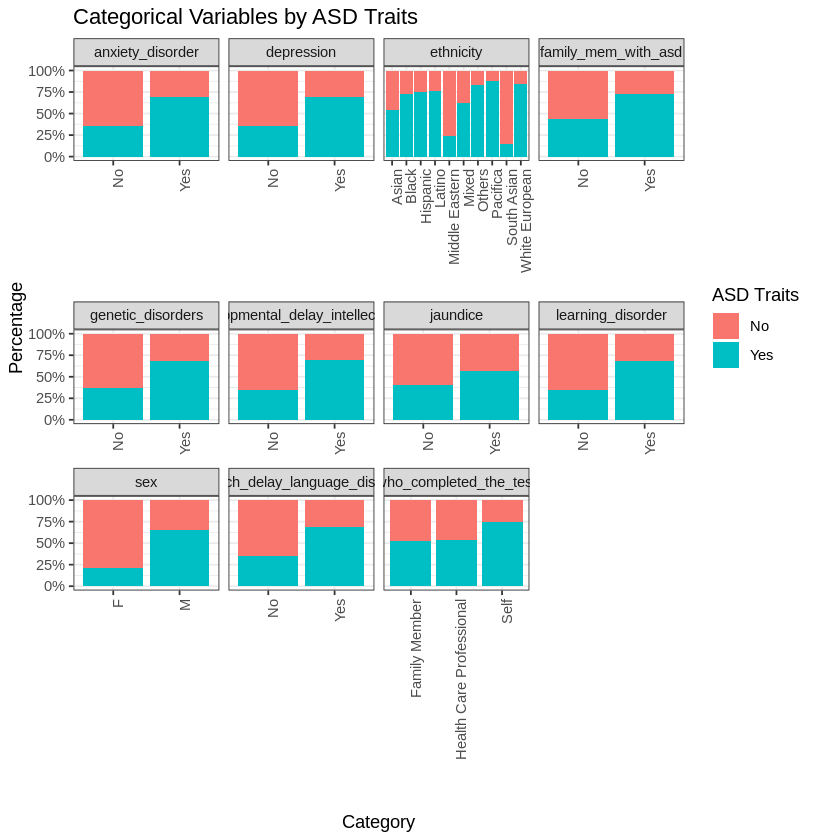

In [29]:
ggplot(asd_categorical_2, aes(x = category, fill = asd_traits)) +
  geom_bar(position = "fill") +
  facet_wrap(~ variable, scales = "free_x") +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Categorical Variables by ASD Traits",
    x = "Category",
    y = "Percentage",
    fill = "ASD Traits"       # Proportion plot for categorical values
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1
    )
  )

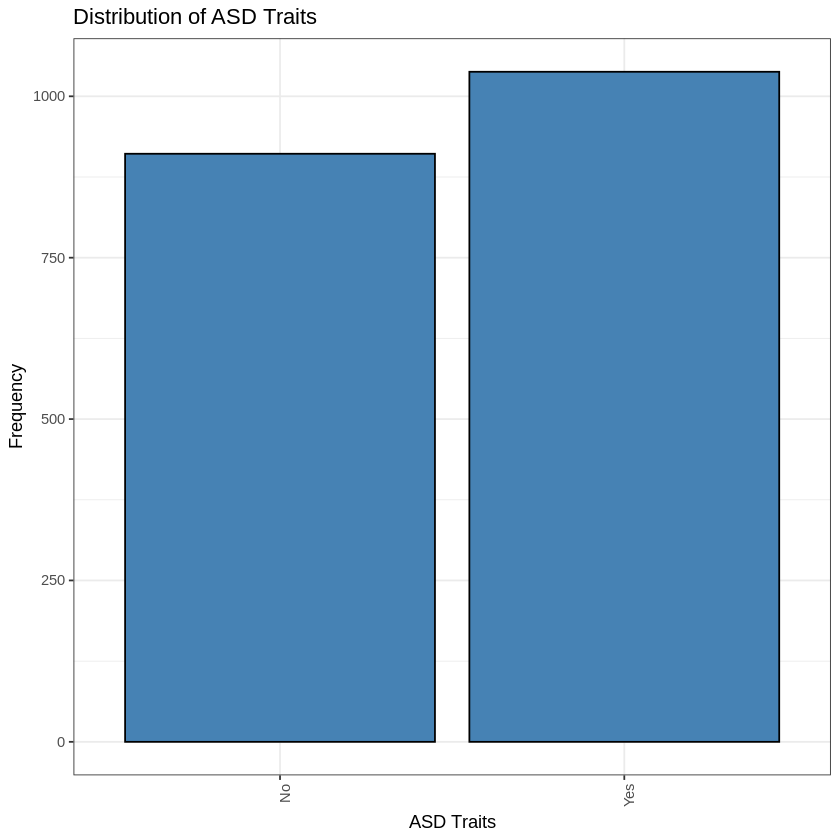

In [30]:
ggplot(df1, aes(x = asd_traits)) +
    geom_bar(
      fill = "steelblue",
      color = "black"
    ) +
    labs(
      title = paste("Distribution of ASD Traits"),  # Running a loop for bar plots of all categorical values
      x = "ASD Traits",
      y = "Frequency"
    ) +
    theme_bw() +
    theme(
      axis.text.x = element_text(
        angle = 90,
        hjust = 1
      )
    )

In [31]:
asd_numeric_2 <- df1 %>%
  select(asd_traits, all_of(numeric_vars)) %>%
  pivot_longer(
    cols = all_of(numeric_vars),    # All the numeric columns per patient id are added to one column with their
                                               # corresponding values in another column "indexed" by asd_traits
    names_to = "variable",
    values_to = "value"
  )

  asd_numeric_2

asd_traits,variable,value
<chr>,<chr>,<int>
No,age_years,2
Yes,age_years,3
Yes,age_years,3
Yes,age_years,2
Yes,age_years,2
Yes,age_years,2
Yes,age_years,3
Yes,age_years,3
No,age_years,3


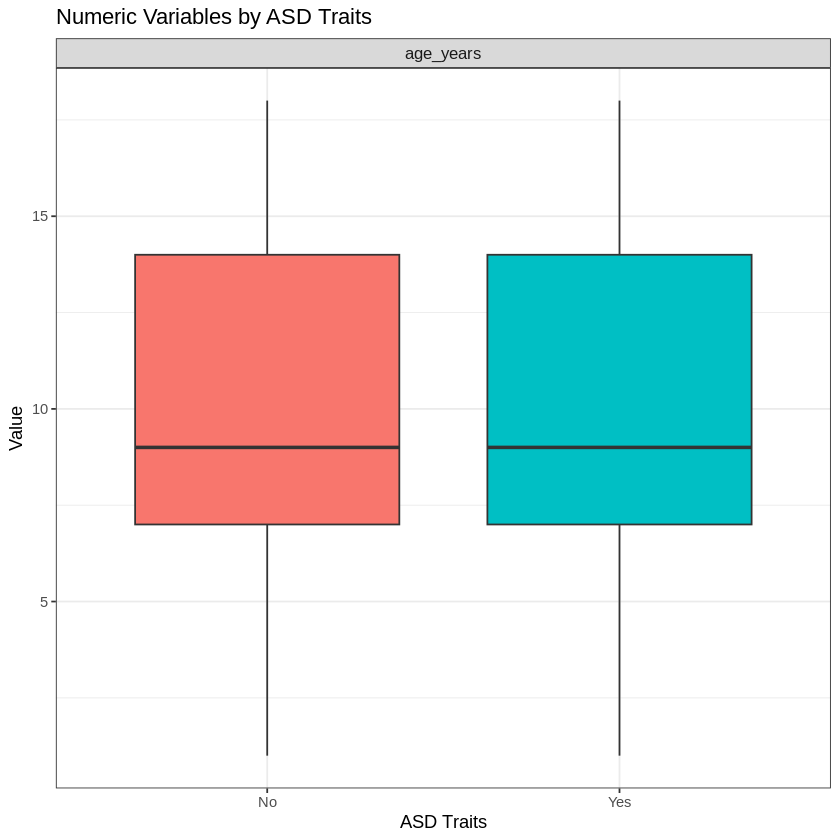

In [32]:
ggplot(asd_numeric_2, aes(x = asd_traits, y = value, fill = asd_traits)) +
  geom_boxplot(na.rm = TRUE) +
  facet_wrap(~ variable, scales = "free_y") +
  labs(
    title = "Numeric Variables by ASD Traits",
    x = "ASD Traits",                             # Boxplot of numeric columns
    y = "Value"
  ) +
  theme_bw() +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 10)
  )

In [33]:
asd_model <- df1

In [34]:
asd_model <- asd_model %>%
  mutate(
    asd_traits = factor(
      asd_traits,
      levels = c("No", "Yes")
    )
  )

In [35]:
asd_model[categorical_predictors] <- lapply(
  asd_model[categorical_predictors],
  factor
)

In [36]:
asd_model <- asd_model %>%
  select(-case_no_patients)

In [37]:
asd_model

age_years,speech_delay_language_disorder,learning_disorder,genetic_disorders,depression,global_developmental_delay_intellectual_disability,anxiety_disorder,sex,ethnicity,jaundice,family_mem_with_asd,who_completed_the_test,asd_traits
<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
2,Yes,Yes,Yes,Yes,Yes,Yes,F,Middle Eastern,Yes,No,Family Member,No
3,Yes,Yes,Yes,Yes,Yes,Yes,M,White European,Yes,No,Family Member,Yes
3,Yes,Yes,Yes,Yes,Yes,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
2,Yes,Yes,No,Yes,Yes,Yes,M,Hispanic,No,No,Family Member,Yes
2,Yes,Yes,No,Yes,Yes,Yes,F,White European,No,No,Family Member,Yes
2,Yes,Yes,No,Yes,Yes,Yes,M,Black,No,No,Family Member,Yes
3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
3,Yes,Yes,Yes,Yes,Yes,Yes,M,Asian,Yes,No,Family Member,Yes
3,Yes,Yes,No,Yes,Yes,Yes,M,Asian,No,No,Family Member,No


In [38]:
dim(asd_model)

[1] 1949   13

In [39]:
install.packages("caret") # The caret package in R is a comprehensive toolkit that simplifies training, tuning, and evaluating ML models

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




Reference for the ML implementation:- Reliable Autism Spectrum Disorder Diagnosis for Pediatrics Using Machine Learning and Explainable AI

Diagnostics 2024, 14(22), 2504; https://doi.org/10.3390/diagnostics14222504

In [40]:
library(caret)

set.seed(123)

train_index <- createDataPartition(
  asd_model$asd_traits,
  p = 0.80,               # 80% Train Data, 20% Test Data
  list = FALSE
)

train_data <- asd_model[train_index, ]
test_data  <- asd_model[-train_index, ]

Loading required package: lattice



In [41]:
prop.table(table(train_data$asd_traits))
                                            # Checking the class proportion in train and test data; Should be similar in both data
prop.table(table(test_data$asd_traits))


       No       Yes 
0.4673077 0.5326923 


       No       Yes 
0.4678663 0.5321337 

In [42]:
ctrl <- trainControl(
  method = "cv",
  number = 10,   # 10-Fold Cross Validation: Trains on 90% train data and tests on 10% train data
  classProbs = TRUE,
  savePredictions = "final",
  summaryFunction = twoClassSummary
)

In [128]:
 train_data$asd_traits <- relevel(
  train_data$asd_traits,
  ref = "Yes"  # Making the Yes or positive class the reference or first label
 )

# train_data$asd_traits <- factor(
#  train_data$asd_traits,
#  levels = c("No", "Yes")
#)

test_data$asd_traits <- factor(
  test_data$asd_traits,
  levels = levels(train_data$asd_traits)
)

In [129]:
levels(train_data$asd_traits)

[1] "Yes" "No"

In [130]:
set.seed(123)

logistic_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "glm",  # Logistic Regression Model - Linear Model for binary outcomes
  family = binomial, # The binomial family tells R that you're modelling a binary outcome.
  metric = "ROC", # Use ROC-AUC as the primary performance metric when evaluating the model in 10-fold cross validation
  trControl = ctrl
)

In [131]:
logistic_model # Model Performance on train set

Generalized Linear Model 

1560 samples
  12 predictor
   2 classes: 'Yes', 'No' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 1404, 1404, 1404, 1403, 1404, 1404, ... 
Resampling results:

  ROC        Sens       Spec     
  0.8331265  0.8603701  0.7559361


In [132]:
summary(logistic_model)


Call:
NULL

Coefficients:
                                                       Estimate Std. Error
(Intercept)                                             1.81639    0.29629
age_years                                              -0.01684    0.01553
speech_delay_language_disorderYes                      -0.65159    1.64697
learning_disorderYes                                   -0.05600    0.67907
genetic_disordersYes                                    0.33005    0.43474
depressionYes                                          16.41159  506.12157
global_developmental_delay_intellectual_disabilityYes -15.91104  506.11786
anxiety_disorderYes                                    -0.95294    1.29911
sexM                                                   -1.59811    0.17109
ethnicityBlack                                         -0.22848    0.37844
ethnicityHispanic                                      -0.20157    0.44395
ethnicityLatino                                        -1.08368    0.6106

In [133]:
levels(train_data$sex)
# Distribution of ASD traits by gender
table(train_data$sex, train_data$asd_traits)

[1] "F" "M"

   
    Yes  No
  F  88 339
  M 743 390

In [134]:
glm_model <- glm(
  asd_traits ~ .,
  data = train_data, # To calculate the odds
  family = binomial
)

summary(glm_model)


Call:
glm(formula = asd_traits ~ ., family = binomial, data = train_data)

Coefficients:
                                                       Estimate Std. Error
(Intercept)                                             1.81639    0.29629
age_years                                              -0.01684    0.01553
speech_delay_language_disorderYes                      -0.65159    1.64697
learning_disorderYes                                   -0.05600    0.67907
genetic_disordersYes                                    0.33005    0.43474
depressionYes                                          16.41159  506.12157
global_developmental_delay_intellectual_disabilityYes -15.91104  506.11786
anxiety_disorderYes                                    -0.95294    1.29911
sexM                                                   -1.59811    0.17109
ethnicityBlack                                         -0.22848    0.37844
ethnicityHispanic                                      -0.20157    0.44395
ethnicityL

In [135]:
exp(coef(glm_model)["sexM"]) # Odds

sexM 
0.2022777

In [136]:
sex_only <- glm(
  asd_traits ~ sex,
  data = train_data,
  family = binomial
)

summary(sex_only)


Call:
glm(formula = asd_traits ~ sex, family = binomial, data = train_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.3487     0.1196   11.27   <2e-16 ***
sexM         -1.9932     0.1350  -14.77   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2155.9  on 1559  degrees of freedom
Residual deviance: 1893.3  on 1558  degrees of freedom
AIC: 1897.3

Number of Fisher Scoring iterations: 4


In [137]:
exp(coef(sex_only)["sexM"])

sexM 
0.136257

ROC-AUC: It measures how well the model discriminates between ASD (Yes) and non-ASD (No) across all possible classification thresholds.

AUC ≈ 0.833 means that, approximately, an ASD case will receive a higher predicted probability of ASD than a non-ASD case about 83.3% of the time. A randomly selected ASD-positive (Yes) individual receives a higher predicted probability of Yes/ASD than a randomly selected ASD-negative (No) individual approximately 83.3% of the time.

Logistic regression is one of the most established approaches for predicting a binary outcome. Therefore, it gives you a clinically/statistically interpretable benchmark against which the machine-learning models can be compared.

Unlike KNN, Random Forest, or XGBoost, logistic regression provides coefficients that can be interpreted in terms of the association between predictors and ASD odds.

Because "Yes" is the reference level and "No" is the second level, the binomial GLM models the odds of the ASD-negative (No) class relative to the ASD-positive (Yes) class.

For eg: "In the logistic regression model with 'No' as the modeled outcome, the odds of being ASD-negative among males were approximately 80% (1 - 0.2) lower than among females, holding the other predictors constant."

For a two-level response factor, glm(..., family = binomial) models the probability of the second level.

In [47]:
install.packages("glmnet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppEigen’




In [48]:
library(glmnet)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 5.0



In [49]:
set.seed(123)

lasso_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "glmnet",
  family = "binomial",
  metric = "ROC",
  trControl = ctrl,
  tuneLength = 20
)

In [50]:
lasso_model$bestTune

,alpha,lambda
,<dbl>,<dbl>
278,0.7157895,0.1075774


In [51]:
coef(lasso_model$finalModel, s = lasso_model$bestTune$lambda)

22 x 1 sparse Matrix of class "dgCMatrix"
                                                      s=0.1075774
(Intercept)                                            0.72787514
age_years                                              .         
speech_delay_language_disorderYes                     -0.09909868
learning_disorderYes                                   .         
genetic_disordersYes                                   .         
depressionYes                                         -0.07780169
global_developmental_delay_intellectual_disabilityYes -0.17065287
anxiety_disorderYes                                   -0.06430284
sexM                                                  -0.79028212
ethnicityBlack                                         .         
ethnicityHispanic                                      .         
ethnicityLatino                                        .         
ethnicityMiddle Eastern                                0.57148446
ethnicityMixed                    

In [52]:
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [53]:
library(randomForest)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine




In [54]:
set.seed(123)

rf_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "rf",
  metric = "ROC",
  trControl = ctrl,
  tuneLength = 5,
  importance = TRUE
)

In [55]:
varImp(rf_model)

rf variable importance

  only 20 most important variables shown (out of 21)

                                                      Importance
sexM                                                      100.00
ethnicityWhite European                                    94.29
ethnicityMiddle Eastern                                    90.35
family_mem_with_asdYes                                     79.91
global_developmental_delay_intellectual_disabilityYes      75.78
anxiety_disorderYes                                        69.02
depressionYes                                              68.46
speech_delay_language_disorderYes                          56.43
genetic_disordersYes                                       44.93
who_completed_the_testHealth Care Professional             41.62
learning_disorderYes                                       37.49
age_years                                                  34.97
ethnicityLatino                                            32.43
jaundiceYes 

In [57]:
install.packages("kernlab")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [58]:
library(kernlab)


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha




In [59]:
set.seed(123)

svm_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "svmRadial",
  metric = "ROC",
  trControl = ctrl,
  preProcess = c("center", "scale"),
  tuneLength = 5
)

In [60]:
set.seed(123)

knn_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "knn",
  metric = "ROC",
  trControl = ctrl,
  preProcess = c("center", "scale"),
  tuneLength = 10
)

In [61]:
install.packages("gbm")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [62]:
library(gbm)

Loaded gbm 2.3.1

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



In [63]:
set.seed(123)

gbm_model <- train(
  asd_traits ~ .,
  data = train_data,
  method = "gbm",
  metric = "ROC",
  trControl = ctrl,
  verbose = FALSE,
  tuneLength = 5
)

In [90]:
# Additional Metrics like accuracy, F1 score, area under the precision–recall curve (prAUC), precision, and recall.
# Run XGBoost Model
# Run significance tests based on the paper
# Document learnings

In [75]:
# 1. Install remotes package if missing
if (!requireNamespace("remotes", quietly = TRUE)) {
  install.packages("remotes")
}

# 1. Install xgboost 1.7.8.1 directly from the CRAN archive URL
install.packages(
  "https://cran.r-project.org/src/contrib/Archive/xgboost/xgboost_1.7.8.1.tar.gz",
  repos = NULL,
  type = "source"
)

# 2. Verify the installed version
packageVersion("xgboost")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] ‘1.7.8.1’

In [ ]:
# install.packages("xgboost")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [76]:
library(xgboost)


Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice




In [77]:
packageVersion("xgboost")
packageVersion("caret")
packageVersion("Matrix")

[1] ‘1.7.8.1’

[1] ‘7.0.1’

[1] ‘1.7.6’

In [78]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] xgboost_1.7.8.1      pROC_1.19.0.1        gbm_2.3.1           
 [4] kernlab_0.9-33       randomForest_4.7-1.2 glmnet_5.0          
 [7] Matrix_1.7-6         caret_7.0-1      

In [79]:
# Create dummy-variable specification using the predictors
dummies <- dummyVars(
  ~ .,
  data = train_data %>% select(-asd_traits)
)

# Transform training data
x_train <- predict(
  dummies,
  newdata = train_data %>% select(-asd_traits)
)

# Outcome
y_train <- train_data$asd_traits

set.seed(123)

xgb_model <- train(
  x = x_train,
  y = y_train,
  method = "xgbTree",
  metric = "ROC",
  trControl = ctrl,
  tuneLength = 5
)

xgb_model

[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[17:43:48] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

eXtreme Gradient Boosting 

1560 samples
  32 predictor
   2 classes: 'Yes', 'No' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 1404, 1404, 1404, 1403, 1404, 1404, ... 
Resampling results across tuning parameters:

  eta  max_depth  colsample_bytree  subsample  nrounds  ROC        Sens     
  0.3  1          0.6               0.500       50      0.8301183  0.8615749
  0.3  1          0.6               0.500      100      0.8361405  0.8591796
  0.3  1          0.6               0.500      150      0.8367340  0.8567843
  0.3  1          0.6               0.500      200      0.8334059  0.8627940
  0.3  1          0.6               0.500      250      0.8321238  0.8531555
  0.3  1          0.6               0.625       50      0.8300318  0.8591796
  0.3  1          0.6               0.625      100      0.8341054  0.8591796
  0.3  1          0.6               0.625      150      0.8350421  0.8519507
  0.3  1          0.6               0.625      200    

In [80]:
results <- resamples(
  list(
    Logistic = logistic_model,
    LASSO = lasso_model,
    RandomForest = rf_model,
    SVM = svm_model,
    KNN = knn_model,
    GBM = gbm_model,
    XGBoost = xgb_model
  )
)

In [81]:
summary(results)


Call:
summary.resamples(object = results)

Models: Logistic, LASSO, RandomForest, SVM, KNN, GBM, XGBoost 
Number of resamples: 10 

ROC 
                  Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
Logistic     0.7832151 0.8123453 0.8394537 0.8331265 0.8582300 0.8683138    0
LASSO        0.7875887 0.8282926 0.8369368 0.8385857 0.8584956 0.8857632    0
RandomForest 0.8441987 0.8720086 0.8789817 0.8859961 0.9062264 0.9285475    0
SVM          0.8162238 0.8479122 0.8735765 0.8702626 0.8901519 0.9127744    0
KNN          0.8573197 0.8681301 0.8972190 0.8965825 0.9175400 0.9369980    0
GBM          0.8503053 0.8808591 0.8955273 0.8945704 0.9079056 0.9412100    0
XGBoost      0.8459317 0.8729988 0.8942070 0.8952392 0.9134139 0.9521363    0

Sens 
                  Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
Logistic     0.7951807 0.8343373 0.8614458 0.8603701 0.8795181 0.9277108    0
LASSO        0.7951807 0.8433735 0.8554217 0.8711704 0.9126506 0.9638554   

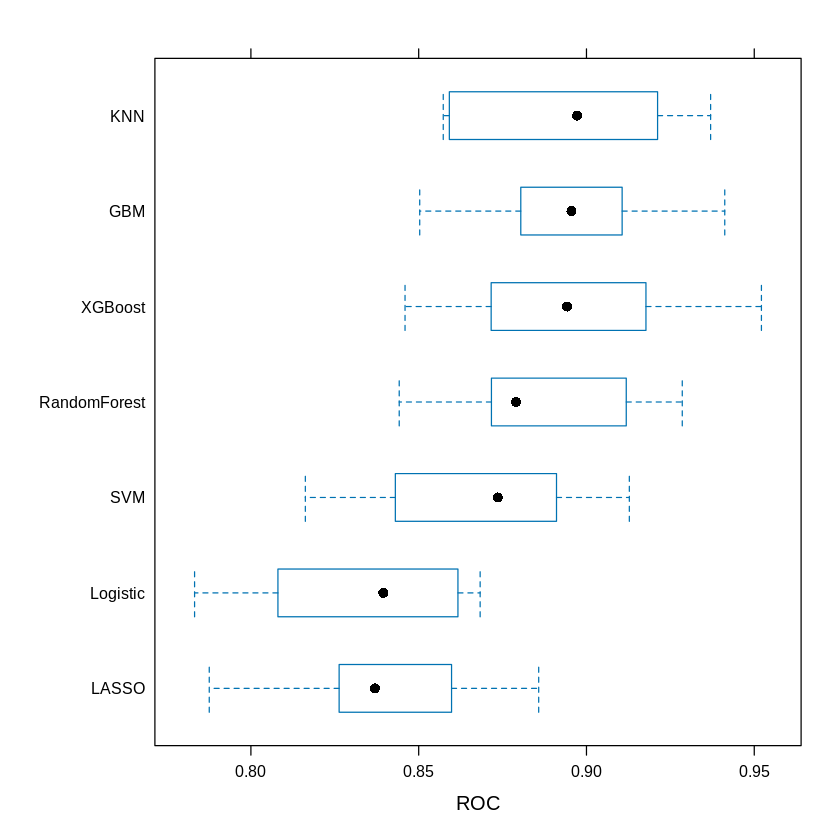

In [83]:
bwplot(results, metric = "ROC")

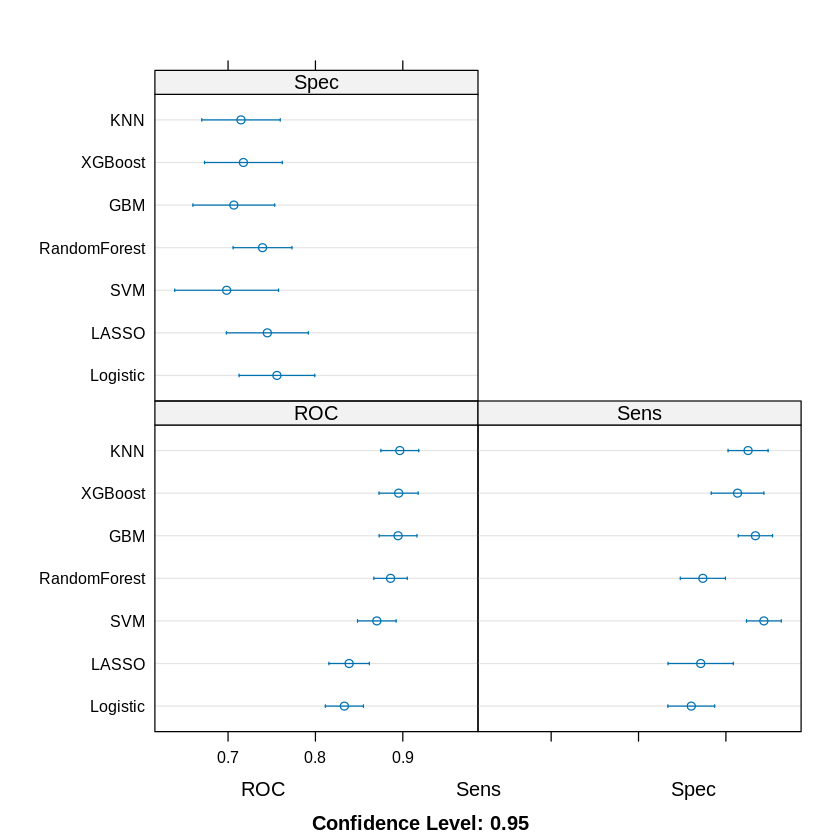

In [84]:
dotplot(results)

In [82]:
x_test <- predict(
  dummies,
  newdata = test_data %>% select(-asd_traits)
)

In [85]:
# Predicted probability of ASD = "Yes"

logistic_pred <- predict(
  logistic_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

lasso_pred <- predict(
  lasso_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

rf_pred <- predict(
  rf_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

svm_pred <- predict(
  svm_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

knn_pred <- predict(
  knn_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

gbm_pred <- predict(
  gbm_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

xgb_pred <- predict(
  xgb_model,
  newdata = x_test,
  type = "prob"
)[, "Yes"]

In [86]:
predictions <- list(
  Logistic = logistic_pred,
  LASSO = lasso_pred,
  RandomForest = rf_pred,
  SVM = svm_pred,
  KNN = knn_pred,
  GBM = gbm_pred,
  XGBoost = xgb_pred
)

In [87]:
actual <- test_data$asd_traits

In [91]:
levels(actual)

[1] "Yes" "No"

In [92]:
library(pROC)

roc_results <- lapply(
  predictions,
  function(pred) {
    roc(
      response = actual,
      predictor = pred,
      levels = c("No", "Yes"),
      direction = "<"
    )
  }
)

auc_results <- sapply(
  roc_results,
  auc
)

auc_results

Logistic        LASSO RandomForest          SVM          KNN          GBM 
   0.8617614    0.8696714    0.9061953    0.9070977    0.9245899    0.9054786 
     XGBoost 
   0.9001168

In [93]:
auc_table <- data.frame(
  Model = names(auc_results),
  ROC_AUC = as.numeric(auc_results)
)

auc_table

Model,ROC_AUC
<chr>,<dbl>
Logistic,0.8617614
LASSO,0.8696714
RandomForest,0.9061953
SVM,0.9070977
KNN,0.9245899
GBM,0.9054786
XGBoost,0.9001168


In [94]:
install.packages("PRROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [95]:
library(PRROC)

Loading required package: rlang



In [99]:
class_predictions <- lapply(
  predictions,
  function(pred) {
    factor(
      ifelse(pred >= 0.5, "Yes", "No"),
      levels = c("Yes", "No")
    )
  }
)

In [100]:
results <- lapply(
  names(predictions),
  function(model_name) {

    # Probability predictions
    prob <- predictions[[model_name]]

    # Class predictions
    pred_class <- class_predictions[[model_name]]

    # ROC-AUC
    roc_obj <- roc(
      response = actual,
      predictor = prob,
      levels = c("No", "Yes"),
      direction = "<",
      quiet = TRUE
    )

    roc_auc <- as.numeric(auc(roc_obj))

    # Confusion matrix
    cm <- confusionMatrix(
      pred_class,
      actual,
      positive = "Yes"
    )

    # Precision-recall curve
    pr_obj <- pr.curve(
      scores.class0 = prob[actual == "Yes"],
      scores.class1 = prob[actual == "No"],
      curve = FALSE
    )

    pr_auc <- pr_obj$auc.integral

    # Return all metrics
    data.frame(
      Model = model_name,
      ROC_AUC = roc_auc,
      Accuracy = as.numeric(cm$overall["Accuracy"]),
      F1 = as.numeric(cm$byClass["F1"]),
      prAUC = pr_auc,
      Precision = as.numeric(cm$byClass["Pos Pred Value"]),
      Recall = as.numeric(cm$byClass["Sensitivity"])
    )
  }
)

final_results <- do.call(rbind, results)

rownames(final_results) <- NULL

final_results

Model,ROC_AUC,Accuracy,F1,prAUC,Precision,Recall
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic,0.8617614,0.8303342,0.8398058,0.8010003,0.8439024,0.8357488
LASSO,0.8696714,0.8277635,0.8377724,0.8128428,0.8398058,0.8357488
RandomForest,0.9061953,0.8329049,0.8505747,0.8875862,0.8114035,0.8937198
SVM,0.9070977,0.8406170,0.8609865,0.8907460,0.8033473,0.9275362
KNN,0.9245899,0.8560411,0.8738739,0.9263590,0.8185654,0.9371981
GBM,0.9054786,0.8251928,0.8468468,0.9074681,0.7932489,0.9082126
XGBoost,0.9001168,0.8303342,0.8513514,0.9011192,0.7974684,0.9130435


In [101]:
logistic_prob <- predict(
  logistic_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

lasso_prob <- predict(
  lasso_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

rf_prob <- predict(
  rf_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

svm_prob <- predict(
  svm_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

knn_prob <- predict(
  knn_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

gbm_prob <- predict(
  gbm_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

xgb_prob <- predict(
  xgb_model,
  newdata = x_test,
  type = "prob"
)[, "Yes"]

In [102]:
length(test_data$asd_traits)

length(logistic_prob)
length(lasso_prob)
length(rf_prob)
length(svm_prob)
length(knn_prob)
length(gbm_prob)
length(xgb_prob)

[1] 389

[1] 389

[1] 389

[1] 389

[1] 389

[1] 389

[1] 389

[1] 389

In [104]:
roc_logistic <- roc(
  response = test_data$asd_traits,
  predictor = logistic_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_lasso <- roc(
  response = test_data$asd_traits,
  predictor = lasso_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_rf <- roc(
  response = test_data$asd_traits,
  predictor = rf_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_svm <- roc(
  response = test_data$asd_traits,
  predictor = svm_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_knn <- roc(
  response = test_data$asd_traits,
  predictor = knn_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_gbm <- roc(
  response = test_data$asd_traits,
  predictor = gbm_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

roc_xgb <- roc(
  response = test_data$asd_traits,
  predictor = xgb_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

In [105]:
auc_results_1 <- data.frame(
  Model = c(
    "Logistic",
    "LASSO",
    "RandomForest",
    "SVM",
    "KNN",
    "GBM",
    "XGBoost"
  ),

  ROC_AUC = c(
    as.numeric(auc(roc_logistic)),
    as.numeric(auc(roc_lasso)),
    as.numeric(auc(roc_rf)),
    as.numeric(auc(roc_svm)),
    as.numeric(auc(roc_knn)),
    as.numeric(auc(roc_gbm)),
    as.numeric(auc(roc_xgb))
  )
)

auc_results_1

Model,ROC_AUC
<chr>,<dbl>
Logistic,0.8617614
LASSO,0.8696714
RandomForest,0.9061953
SVM,0.9070977
KNN,0.9245899
GBM,0.9054786
XGBoost,0.9001168


In [106]:
test_knn_logistic <- roc.test(
  roc_knn,
  roc_logistic,
  paired = TRUE,
  method = "delong"
)

test_knn_lasso <- roc.test(
  roc_knn,
  roc_lasso,
  paired = TRUE,
  method = "delong"
)

test_knn_rf <- roc.test(
  roc_knn,
  roc_rf,
  paired = TRUE,
  method = "delong"
)

test_knn_svm <- roc.test(
  roc_knn,
  roc_svm,
  paired = TRUE,
  method = "delong"
)

test_knn_gbm <- roc.test(
  roc_knn,
  roc_gbm,
  paired = TRUE,
  method = "delong"
)

test_knn_xgb <- roc.test(
  roc_knn,
  roc_xgb,
  paired = TRUE,
  method = "delong"
)

In [107]:
p_values <- c(
  "KNN vs Logistic" = test_knn_logistic$p.value,
  "KNN vs LASSO" = test_knn_lasso$p.value,
  "KNN vs RandomForest" = test_knn_rf$p.value,
  "KNN vs SVM" = test_knn_svm$p.value,
  "KNN vs GBM" = test_knn_gbm$p.value,
  "KNN vs XGBoost" = test_knn_xgb$p.value
)

p_values

KNN vs Logistic        KNN vs LASSO KNN vs RandomForest          KNN vs SVM 
       0.0001008209        0.0004135251        0.0318527976        0.1212097917 
         KNN vs GBM      KNN vs XGBoost 
       0.0279559307        0.0106133652

In [108]:
p_holm <- p.adjust(
  p_values,
  method = "holm"
)

p_holm

KNN vs Logistic        KNN vs LASSO KNN vs RandomForest          KNN vs SVM 
       0.0006049256        0.0020676256        0.0838677920        0.1212097917 
         KNN vs GBM      KNN vs XGBoost 
       0.0838677920        0.0424534607

In [109]:
other_auc <- c(
  "KNN vs Logistic" = as.numeric(auc(roc_logistic)),
  "KNN vs LASSO" = as.numeric(auc(roc_lasso)),
  "KNN vs RandomForest" = as.numeric(auc(roc_rf)),
  "KNN vs SVM" = as.numeric(auc(roc_svm)),
  "KNN vs GBM" = as.numeric(auc(roc_gbm)),
  "KNN vs XGBoost" = as.numeric(auc(roc_xgb))
)

delong_results <- data.frame(
  Comparison = names(other_auc),
  KNN_AUC = as.numeric(auc(roc_knn)),
  Other_AUC = as.numeric(other_auc),
  AUC_Difference = as.numeric(auc(roc_knn)) - other_auc,
  P_value = as.numeric(p_values),
  Holm_adjusted_P = as.numeric(p_holm)
)

delong_results$Significant <- (
  delong_results$Holm_adjusted_P < 0.05
)

delong_results

,Comparison,KNN_AUC,Other_AUC,AUC_Difference,P_value,Holm_adjusted_P,Significant
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
KNN vs Logistic,KNN vs Logistic,0.9245899,0.8617614,0.06282848,0.0001008209,0.0006049256,TRUE
KNN vs LASSO,KNN vs LASSO,0.9245899,0.8696714,0.05491851,0.0004135251,0.0020676256,TRUE
KNN vs RandomForest,KNN vs RandomForest,0.9245899,0.9061953,0.01839465,0.0318527976,0.0838677920,FALSE
KNN vs SVM,KNN vs SVM,0.9245899,0.9070977,0.01749217,0.1212097917,0.1212097917,FALSE
KNN vs GBM,KNN vs GBM,0.9245899,0.9054786,0.01911132,0.0279559307,0.0838677920,FALSE
KNN vs XGBoost,KNN vs XGBoost,0.9245899,0.9001168,0.02447311,0.0106133652,0.0424534607,TRUE
